## 0. Install dependencies

In [1]:
import sys, subprocess

pkgs = [
    "diffusers==0.35.1",
    "transformers==4.57.1",
    "accelerate==1.10.1",
    "datasets==4.8.4",
    "safetensors", "ftfy", "huggingface_hub",
    "peft", "opencv-python-headless",
    "bitsandbytes"
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs, check=True)
print("Install done")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.0 MB/s eta 0:00:00
Install done


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

## 1. Imports

In [2]:
import os
import ast
import hashlib
import json
from pathlib import Path

import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from diffusers import DDPMScheduler, AutoencoderKL, UNet2DConditionModel
from transformers import CLIPTokenizer, CLIPTextModel
from peft import LoraConfig, get_peft_model
from diffusers.optimization import get_scheduler
import bitsandbytes as bnb
import shutil

2026-06-14 07:21:32.002077: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781421692.256904      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781421692.323541      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781421692.892300      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781421692.892329      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781421692.892332      23 computation_placer.cc:177] computation placer alr

## 2. Config

In [3]:
# ── Model & output ──────────────────────────────────────────────────────────
MODEL_NAME  = "nitrosocke/Ghibli-Diffusion"
OUTPUT_DIR  = "/kaggle/working/lora_weights"

# ── Prepared common dataset (Kaggle input) ───────────────────────────────────────
DATA_ROOT     = Path("/kaggle/input/datasets/trongnhantran25/data-common-train")
MANIFEST_PATH = DATA_ROOT / "manifest.csv"
# Fallback nếu Kaggle mount slug khác:
if not MANIFEST_PATH.exists():
    _hits = list(Path("/kaggle/input").rglob("manifest.csv"))
    assert _hits, "Không tìm thấy manifest.csv dưới /kaggle/input"
    MANIFEST_PATH = _hits[0]
    DATA_ROOT     = MANIFEST_PATH.parent

# ── Preprocessing thông số ───────────────────────────────────────────────────
RESOLUTION  = 512          # resize cạnh ngắn → 512, rồi CenterCrop(512)
SEED        = 42

# ── Prompt — toàn bộ ảnh dùng chung 1 prompt ─────────────────────────────────
TRIGGER_TOKEN = "skstyle"
STYLE_PROMPT  = f"{TRIGGER_TOKEN} impressionism style painting"

# ── Training thông số ────────────────────────────────────────────────────────
BATCH_SIZE        = 4
GRAD_ACCUM_STEPS  = 2
LEARNING_RATE     = 1e-4
MAX_TRAIN_STEPS   = 5000
LORA_RANK         = 64
LORA_ALPHA        = 64
NUM_WORKERS       = 2
SAVE_EVERY        = 500
VAL_STEPS         = 5
NUM_WARMUP_STEPS  = 350

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 3. Load prepared splits from `data-common-train` manifest

In [4]:
# Đọc manifest đã chuẩn bị sẵn (đã clean + dedup + split 80/10/10).
manifest = pd.read_csv(MANIFEST_PATH)

# Giữ đúng STYLE_PROMPT cũ — xác nhận manifest không dùng prompt khác.
unique_prompts = sorted(manifest["prompt"].dropna().unique().tolist())
assert unique_prompts == [STYLE_PROMPT], (
    f"Manifest prompt khác STYLE_PROMPT: {unique_prompts} vs [{STYLE_PROMPT}]. "
    "Kiểm tra lại STYLE_PROMPT ở cell Config."
)

train_df = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_df   = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_df  = manifest[manifest["split"] == "test"].reset_index(drop=True)

total = len(manifest)
assert len(train_df) and len(val_df) and len(test_df), "Có split rỗng trong manifest."
assert len(train_df) + len(val_df) + len(test_df) == total, "Tổng split != tổng manifest."

print(f"Manifest   : {MANIFEST_PATH}")
print(f"Tổng ảnh   : {total:,}")
print(f"Train      : {len(train_df):,}  ({len(train_df)/total*100:.1f}%)")
print(f"Validation : {len(val_df):,}  ({len(val_df)/total*100:.1f}%)")
print(f"Style test : {len(test_df):,}  ({len(test_df)/total*100:.1f}%)")


Manifest   : /kaggle/input/datasets/trongnhantran25/data-common-train/manifest.csv
Tổng ảnh   : 13,060
Train      : 10,448  (80.0%)
Validation : 1,306  (10.0%)
Style test : 1,306  (10.0%)


## 7. Dataset class (đọc thẳng từ disk, không save ra disk)

In [5]:
class ImpressionismDataset(Dataset):
    """
    Đọc ảnh trực tiếp từ data-common-train directory.
    Toàn bộ ảnh dùng chung 1 prompt: STYLE_PROMPT
    Transforms:
      - train      : Resize(512, BILINEAR) → CenterCrop(512) → RandomHorizontalFlip(p=0.5)
                     → ToTensor() → Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
      - val / test : Resize(512, BILINEAR) → CenterCrop(512)
                     → ToTensor() → Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
    Giá trị sau normalize: [-1, 1]
    """

    TRAIN_TRANSFORMS = transforms.Compose([
        transforms.Resize(RESOLUTION, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(RESOLUTION),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
    ])

    EVAL_TRANSFORMS = transforms.Compose([
        transforms.Resize(RESOLUTION, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(RESOLUTION),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
    ])

    def __init__(self, df, base_dir, split="train"):
        self.df        = df.reset_index(drop=True)
        self.base_dir  = Path(base_dir)
        self.transform = self.TRAIN_TRANSFORMS if split == "train" else self.EVAL_TRANSFORMS

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = self.base_dir / Path(row["image_path"])
        img      = Image.open(img_path).convert("RGB")
        return {
            "pixel_values": self.transform(img),
            "prompt":       STYLE_PROMPT,
        }

## 8. Build DataLoaders

In [6]:
print("Building datasets...")
train_dataset = ImpressionismDataset(train_df, DATA_ROOT, split="train")
val_dataset   = ImpressionismDataset(val_df,   DATA_ROOT, split="val")
test_dataset  = ImpressionismDataset(test_df,  DATA_ROOT, split="style_test")

train_dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS
)
val_dataloader = DataLoader(
    val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
test_dataloader = DataLoader(
    test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

print(f"Train batches : {len(train_dataloader)}")
print(f"Val   batches : {len(val_dataloader)}")
print(f"Test  batches : {len(test_dataloader)}")

Building datasets...
Train batches : 2612
Val   batches : 327
Test  batches : 327


## 9. Load pretrained models

In [7]:
print("Loading models...")
tokenizer     = CLIPTokenizer.from_pretrained(MODEL_NAME, subfolder="tokenizer")
text_encoder  = CLIPTextModel.from_pretrained(MODEL_NAME, subfolder="text_encoder")
vae           = AutoencoderKL.from_pretrained(MODEL_NAME, subfolder="vae")
unet          = UNet2DConditionModel.from_pretrained(MODEL_NAME, subfolder="unet")
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_NAME, subfolder="scheduler")

Loading models...


tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/581 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/748 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

## 10. Move to device & freeze

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
text_encoder.to(device, dtype=torch.float16)
vae.to(device,          dtype=torch.float16)
unet.to(device,         dtype=torch.float32)   # float32 for LoRA training

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

print("Loaded model!")

Loaded model!


## 11. Apply LoRA to UNet

In [9]:
print("Applying LoRA to UNet...")
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)
unet_lora = get_peft_model(unet, lora_config)

def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_parameters(unet_lora)
print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")
print(f"Trainable ratio      : {100 * trainable / total:.4f}%")

Applying LoRA to UNet...
Total parameters     : 872,275,908
Trainable parameters : 12,754,944
Trainable ratio      : 1.4623%


## 12. Optimizer & LR scheduler

In [10]:
optimizer = bnb.optim.AdamW8bit(unet_lora.parameters(), lr=LEARNING_RATE)

lr_scheduler = get_scheduler(
    "cosine",
    optimizer=optimizer,
    num_warmup_steps=NUM_WARMUP_STEPS,
    num_training_steps=MAX_TRAIN_STEPS,
)

## 13. Training loop

In [11]:
print("Preparing training loop...")
unet_lora.train()

scaler       = torch.amp.GradScaler(device="cuda")
global_step  = 0
best_val_loss = float("inf")

train_loss_history = []   # (step, loss)
val_loss_history   = []   # (step, loss)

# Resume from checkpoint if exists
checkpoints = [d for d in os.listdir(OUTPUT_DIR) if d.startswith("checkpoint-")]
if checkpoints:
    checkpoints.sort(key=lambda x: int(x.split("-")[1]))
    latest_checkpoint      = checkpoints[-1]
    latest_checkpoint_path = os.path.join(OUTPUT_DIR, latest_checkpoint)
    unet_lora.load_adapter(latest_checkpoint_path, adapter_name="default")
    opt_path = os.path.join(latest_checkpoint_path, "optimizer.pt")
    sch_path = os.path.join(latest_checkpoint_path, "scheduler.pt")
    if os.path.exists(opt_path):
        optimizer.load_state_dict(torch.load(opt_path))
    if os.path.exists(sch_path):
        lr_scheduler.load_state_dict(torch.load(sch_path))
    global_step = int(latest_checkpoint.split("-")[1])
    print(f"Continue {global_step} / {MAX_TRAIN_STEPS}")
else:
    print("Start at step 0")

progress_bar = tqdm(total=MAX_TRAIN_STEPS, desc="Steps")
progress_bar.update(global_step)

fixed_val_timesteps = torch.linspace(
    0, noise_scheduler.config.num_train_timesteps - 1, 10
).long().to(device)

text_inputs = tokenizer(
    [STYLE_PROMPT], padding="max_length",
    max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt"
)
text_input_ids = text_inputs.input_ids.to(device) 

for epoch in range(999):
    for step, batch in enumerate(train_dataloader):
        pixel_values = batch["pixel_values"].to(device, dtype=torch.float16)
        latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor

        noise     = torch.randn_like(latents)
        bsz       = latents.shape[0]
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        ids = text_input_ids.expand(bsz, -1)
        encoder_hidden_states = text_encoder(ids)[0]

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            noise_pred = unet_lora(noisy_latents, timesteps, encoder_hidden_states).sample
            loss = F.mse_loss(noise_pred.float(), noise.float(), reduction="mean")
            loss = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            lr_scheduler.step()
            optimizer.zero_grad()

            global_step += 1
            progress_bar.update(1)
            progress_bar.set_postfix(train_loss=loss.item() * GRAD_ACCUM_STEPS)
            train_loss_history.append((global_step, loss.item() * GRAD_ACCUM_STEPS))

            if global_step % SAVE_EVERY == 0:
                torch.cuda.empty_cache()
                unet_lora.eval()
                val_losses = []

                with torch.no_grad():
                    for i, val_batch in enumerate(val_dataloader):
                        if i >= VAL_STEPS:
                            break
                        vp = val_batch["pixel_values"].to(device, dtype=torch.float16)

                        lat = vae.encode(vp).latent_dist.sample() * vae.config.scaling_factor
                        enc = text_encoder(text_input_ids.expand(vp.shape[0], -1))[0]

                        bin_losses = []
                        for ts_val in fixed_val_timesteps:
                            ts = ts_val.expand(lat.shape[0])
                            n  = torch.randn_like(lat)
                            nl = noise_scheduler.add_noise(lat, n, ts)
                            with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
                                pred = unet_lora(nl, ts, enc).sample
                                bin_losses.append(F.mse_loss(pred.float(), n.float()).item())
                        val_losses.append(sum(bin_losses) / len(bin_losses))

                avg_val_loss = sum(val_losses) / len(val_losses)
                val_loss_history.append((global_step, avg_val_loss))
                print(f"\n[Validation] Step {global_step} | Val Loss: {avg_val_loss:.4f}")

                if avg_val_loss < best_val_loss:
                    best_val_loss = avg_val_loss
                    best_path = os.path.join(OUTPUT_DIR, "best")
                    unet_lora.save_pretrained(best_path)
                    print(f"New best model! (val loss: {best_val_loss:.4f}) → {best_path}")

                save_path = os.path.join(OUTPUT_DIR, f"checkpoint-{global_step}")
                unet_lora.save_pretrained(save_path)
                torch.save(optimizer.state_dict(),    os.path.join(save_path, "optimizer.pt"))
                torch.save(lr_scheduler.state_dict(), os.path.join(save_path, "scheduler.pt"))

                torch.cuda.empty_cache()
                unet_lora.train()

            if global_step >= MAX_TRAIN_STEPS:
                break
    if global_step >= MAX_TRAIN_STEPS:
        break

print(f"\nSaving final LoRA weights to {OUTPUT_DIR}...")
unet_lora.save_pretrained(os.path.join(OUTPUT_DIR, "final"))
print("Training Complete!")

Preparing training loop...
Start at step 0


Steps:   0%|          | 0/5000 [00:00<?, ?it/s]


[Validation] Step 500 | Val Loss: 0.2238
New best model! (val loss: 0.2238) → /kaggle/working/lora_weights/best

[Validation] Step 1000 | Val Loss: 0.2237
New best model! (val loss: 0.2237) → /kaggle/working/lora_weights/best

[Validation] Step 1500 | Val Loss: 0.2235
New best model! (val loss: 0.2235) → /kaggle/working/lora_weights/best

[Validation] Step 2000 | Val Loss: 0.2241

[Validation] Step 2500 | Val Loss: 0.2237

[Validation] Step 3000 | Val Loss: 0.2237

[Validation] Step 3500 | Val Loss: 0.2235

[Validation] Step 4000 | Val Loss: 0.2235

[Validation] Step 4500 | Val Loss: 0.2235
New best model! (val loss: 0.2235) → /kaggle/working/lora_weights/best

[Validation] Step 5000 | Val Loss: 0.2236

Saving final LoRA weights to /kaggle/working/lora_weights...
Training Complete!


## 14. Plot training & validation loss

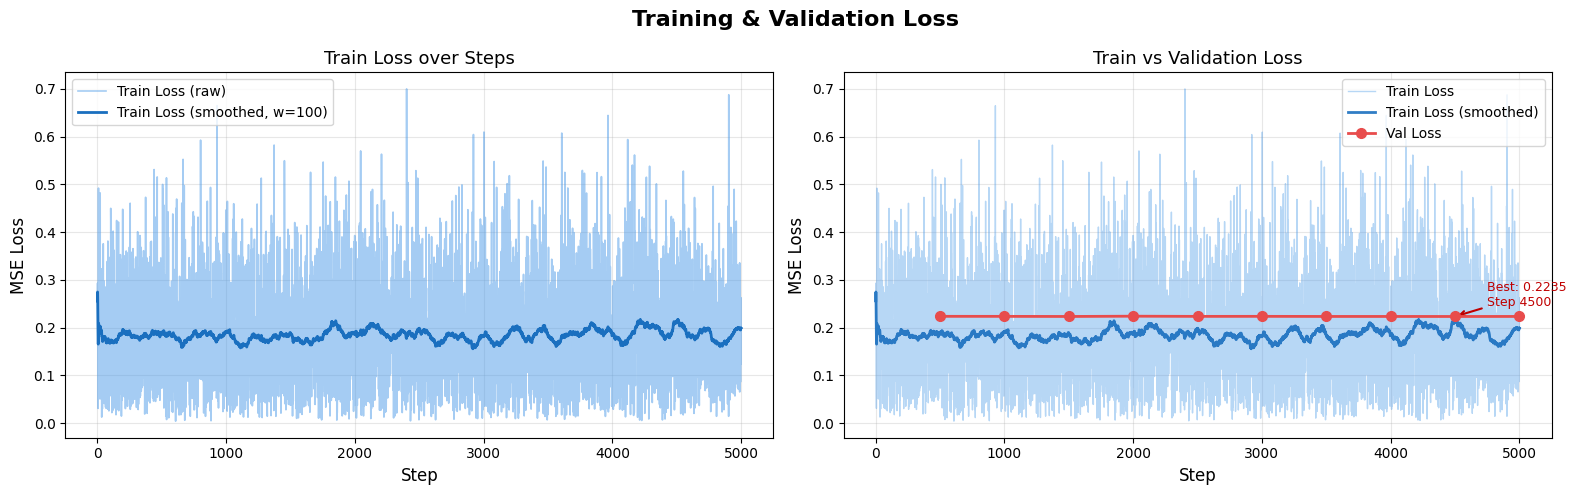

Loss curve saved to: /kaggle/working/lora_weights/loss_curve.png

=== Training Summary ===
  Final Train Loss : 0.224720
  Final Val Loss   : 0.223554
  Best Val Loss    : 0.223464 @ Step 4500
  Total Steps      : 5000


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

if not train_loss_history:
    print("No training history found. Please run training first.")
else:
    train_steps, train_losses = zip(*train_loss_history)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Training & Validation Loss", fontsize=16, fontweight="bold")

    ax1 = axes[0]
    ax1.plot(train_steps, train_losses, color="#4C9BE8", linewidth=1.2,
             alpha=0.5, label="Train Loss (raw)")
    window = max(1, len(train_losses) // 50)
    smooth = [
        sum(train_losses[max(0, i - window):i + 1]) / len(train_losses[max(0, i - window):i + 1])
        for i in range(len(train_losses))
    ]
    ax1.plot(train_steps, smooth, color="#1A6FBF", linewidth=2,
             label=f"Train Loss (smoothed, w={window})")
    ax1.set_xlabel("Step", fontsize=12)
    ax1.set_ylabel("MSE Loss", fontsize=12)
    ax1.set_title("Train Loss over Steps", fontsize=13)
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x)}"))

    ax2 = axes[1]
    ax2.plot(train_steps, train_losses, color="#4C9BE8", linewidth=1, alpha=0.4, label="Train Loss")
    ax2.plot(train_steps, smooth, color="#1A6FBF", linewidth=2, alpha=0.9, label="Train Loss (smoothed)")
    if val_loss_history:
        val_steps, val_losses = zip(*val_loss_history)
        ax2.plot(val_steps, val_losses, color="#E84C4C", linewidth=2,
                 marker="o", markersize=7, label="Val Loss", zorder=5)
        best_step = val_steps[val_losses.index(min(val_losses))]
        best_loss = min(val_losses)
        ax2.annotate(
            f"Best: {best_loss:.4f}\nStep {best_step}",
            xy=(best_step, best_loss),
            xytext=(best_step + len(train_steps) * 0.05, best_loss * 1.1),
            fontsize=9, color="#C00000",
            arrowprops=dict(arrowstyle="->", color="#C00000", lw=1.5)
        )
    else:
        print("No validation history found (computed every SAVE_EVERY steps).")
    ax2.set_xlabel("Step", fontsize=12)
    ax2.set_ylabel("MSE Loss", fontsize=12)
    ax2.set_title("Train vs Validation Loss", fontsize=13)
    ax2.legend(); ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x)}"))

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/loss_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Loss curve saved to: {OUTPUT_DIR}/loss_curve.png")

    print("\n=== Training Summary ===")
    print(f"  Final Train Loss : {train_losses[-1]:.6f}")
    if val_loss_history:
        val_steps, val_losses = zip(*val_loss_history)
        print(f"  Final Val Loss   : {val_losses[-1]:.6f}")
        print(f"  Best Val Loss    : {min(val_losses):.6f} @ Step {val_steps[val_losses.index(min(val_losses))]}")
    print(f"  Total Steps      : {train_steps[-1]}")

## 15. Install evaluation dependencies (FID / KID)

In [13]:
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "torchmetrics[image]",
    "torch-fidelity",
], check=True)
print("Eval deps ready (torchmetrics[image] + torch-fidelity)")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.4 MB/s eta 0:00:00
Eval deps ready (torchmetrics[image] + torch-fidelity)


## 16. Generate images from best LoRA checkpoint

Dùng  load best LoRA weights, generate  ảnh từ prompt,
lưu vào . Song song đó copy real test images vào  để tính FID/KID.

In [14]:
import os, gc
import pandas as pd
import torch
from pathlib import Path
from contextlib import nullcontext
from tqdm.auto import tqdm
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from peft import PeftModel

# ── Eval config — khớp chính xác với chonnhancode-backup ─────────────
STYLE_EVAL_PROMPTS = [
    f"a rural landscape under warm sunlight, {STYLE_PROMPT}",
    f"boats floating on a river at sunset, {STYLE_PROMPT}",
    f"a blooming garden in spring, {STYLE_PROMPT}",
    f"a portrait of a young woman, {STYLE_PROMPT}",
    f"a quiet city boulevard after rain, {STYLE_PROMPT}",
    f"people sitting at an outdoor cafe, {STYLE_PROMPT}",
    f"a lake reflecting morning light, {STYLE_PROMPT}",
    f"a countryside cottage surrounded by trees, {STYLE_PROMPT}",
    f"a vase of colorful flowers on a table, {STYLE_PROMPT}",
    f"a village street in soft afternoon light, {STYLE_PROMPT}",
]
STYLE_EVAL_SEED                = 2026
STYLE_EVAL_NUM_INFERENCE_STEPS = 30
STYLE_EVAL_GUIDANCE_SCALE      = 7.5
STYLE_EVAL_MAX_IMAGES          = None   # None = dùng toàn bộ test split

# Metric config (dùng ở cell sau) — giống hệt backup
METRIC_BATCH_SIZE = 16
KID_SUBSETS       = 50
KID_SUBSET_SIZE   = 100

BEST_LORA_PATH     = os.path.join(OUTPUT_DIR, "best")
STYLE_EVAL_DIR     = os.path.join(OUTPUT_DIR, "style_evaluation")
BASE_GENERATED_DIR = os.path.join(STYLE_EVAL_DIR, "generated_base")
LORA_GENERATED_DIR = os.path.join(STYLE_EVAL_DIR, "generated_lora")
os.makedirs(STYLE_EVAL_DIR, exist_ok=True)
os.makedirs(BASE_GENERATED_DIR, exist_ok=True)
os.makedirs(LORA_GENERATED_DIR, exist_ok=True)

assert os.path.isdir(BEST_LORA_PATH), f"Không tìm thấy best LoRA: {BEST_LORA_PATH}"

def get_autocast_context():
    if device == "cuda":
        return torch.autocast("cuda", dtype=torch.float16)
    return nullcontext()

# ── Step 1: jobs table (prompt + seed + real ref cho từng ảnh) ───────────
num_eval_images = (len(test_df) if STYLE_EVAL_MAX_IMAGES is None
                   else min(STYLE_EVAL_MAX_IMAGES, len(test_df)))
assert num_eval_images >= 2, "Cần ít nhất 2 ảnh để chạy style evaluation."

real_style_test_paths = [DATA_ROOT / test_df.iloc[i]["image_path"]
                         for i in range(num_eval_images)]

style_eval_jobs = []
for image_index in range(num_eval_images):
    style_eval_jobs.append({
        "image_index":         image_index,
        "prompt":              STYLE_EVAL_PROMPTS[image_index % len(STYLE_EVAL_PROMPTS)],
        "seed":                STYLE_EVAL_SEED + image_index,
        "real_reference_path": str(real_style_test_paths[image_index]),
    })
style_eval_jobs_df = pd.DataFrame(style_eval_jobs)
style_eval_jobs_df.to_csv(os.path.join(STYLE_EVAL_DIR, "style_evaluation_jobs.csv"), index=False)
print("Số ảnh dùng đánh giá:", num_eval_images)

# ── Step 2: build inference pipeline (giữ MODEL_NAME = Ghibli) ──────────
def load_evaluation_pipeline():
    p = StableDiffusionPipeline.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16,
        safety_checker=None, requires_safety_checker=False,
    ).to(device)
    p.scheduler = DPMSolverMultistepScheduler.from_config(p.scheduler.config)
    p.set_progress_bar_config(disable=True)
    return p

# ── Step 3: generate (verbatim từ backup) ─────────────────────
def generate_style_images(evaluation_pipe, output_dir):
    evaluation_pipe.unet.eval()
    for _, row in tqdm(style_eval_jobs_df.iterrows(),
                       total=len(style_eval_jobs_df),
                       desc=f"Generating {Path(output_dir).name}"):
        image_index = int(row["image_index"])
        generator   = torch.Generator(device=device).manual_seed(int(row["seed"]))
        with torch.no_grad(), get_autocast_context():
            image = evaluation_pipe(
                prompt=row["prompt"],
                num_inference_steps=STYLE_EVAL_NUM_INFERENCE_STEPS,
                guidance_scale=STYLE_EVAL_GUIDANCE_SCALE,
                generator=generator,
                height=RESOLUTION, width=RESOLUTION,
            ).images[0]
        image.save(os.path.join(output_dir, f"image_{image_index:05d}.png"))

# ── Step 4: giải phóng pipe training, gen Base rồi LoRA ─────────────
for _name in ["pipe", "unet_lora", "unet", "vae", "text_encoder", "optimizer"]:
    globals().pop(_name, None)
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()

print("\n[1/2] Base model (Ghibli, no LoRA)")
eval_pipe = load_evaluation_pipeline()
generate_style_images(eval_pipe, BASE_GENERATED_DIR)
del eval_pipe; gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()

print("\n[2/2] Ghibli + best LoRA")
eval_pipe = load_evaluation_pipeline()
eval_pipe.unet = PeftModel.from_pretrained(eval_pipe.unet, BEST_LORA_PATH).merge_and_unload()
generate_style_images(eval_pipe, LORA_GENERATED_DIR)
del eval_pipe; gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()

print("\n===== GENERATION COMPLETE =====")
print("Real style-test images:", len(real_style_test_paths))
print("Base generated folder :", BASE_GENERATED_DIR)
print("LoRA generated folder :", LORA_GENERATED_DIR)


Số ảnh dùng đánh giá: 1306

[1/2] Base model (Ghibli, no LoRA)


model_index.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

...

Generating generated_base:   0%|          | 0/1306 [00:00<?, ?it/s]


[2/2] Ghibli + best LoRA


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Generating generated_lora:   0%|          | 0/1306 [00:00<?, ?it/s]


===== GENERATION COMPLETE =====
Real style-test images: 1306
Base generated folder : /kaggle/working/lora_weights/style_evaluation/generated_base
LoRA generated folder : /kaggle/working/lora_weights/style_evaluation/generated_lora


## 17. Tính FID & KID trên test set

- **FID** (Fréchet Inception Distance): khoảng cách phân phối giữa generated và real. Thấp hơn = tốt hơn.
- **KID** (Kernel Inception Distance): tương tự FID nhưng unbiased, phù hợp khi số mẫu nhỏ.

In [15]:
import os, json
import pandas as pd
import torch
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

# Transform giống hệt backup: Resize512 -> CenterCrop512 -> uint8 [0,255]
metric_transform = transforms.Compose([
    transforms.Resize(RESOLUTION, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop(RESOLUTION),
    transforms.PILToTensor(),
])

class MetricImageDataset(Dataset):
    def __init__(self, image_files):
        self.files = [Path(p) for p in image_files]
        assert len(self.files) > 0, "Không có ảnh để tính metric."
    def __len__(self):
        return len(self.files)
    def __getitem__(self, i):
        with Image.open(self.files[i]) as im:
            return metric_transform(im.convert("RGB"))

def get_generated_files(directory):
    return sorted(p for p in Path(directory).glob("image_*.png") if p.is_file())

def compute_distribution_metrics(real_files, generated_dir, label):
    fake_files = get_generated_files(generated_dir)
    assert len(fake_files) >= 2, f"{label}: không đủ generated images."
    assert len(real_files) >= 2, "Không đủ real style_test images."

    real_loader = DataLoader(MetricImageDataset(real_files),
                             batch_size=METRIC_BATCH_SIZE, shuffle=False, num_workers=0)
    fake_loader = DataLoader(MetricImageDataset(fake_files),
                             batch_size=METRIC_BATCH_SIZE, shuffle=False, num_workers=0)

    subset_size = min(KID_SUBSET_SIZE, len(real_files), len(fake_files))
    assert subset_size >= 2

    fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    kid_metric = KernelInceptionDistance(feature=2048, subsets=KID_SUBSETS,
                                         subset_size=subset_size, normalize=False).to(device)
    with torch.no_grad():
        for imgs in tqdm(real_loader, desc=f"{label}: real", leave=False):
            imgs = imgs.to(device)
            fid_metric.update(imgs, real=True)
            kid_metric.update(imgs, real=True)
        for imgs in tqdm(fake_loader, desc=f"{label}: fake", leave=False):
            imgs = imgs.to(device)
            fid_metric.update(imgs, real=False)
            kid_metric.update(imgs, real=False)
        fid_value = float(fid_metric.compute().cpu())
        kid_mean, kid_std = kid_metric.compute()
        kid_mean = float(kid_mean.cpu()); kid_std = float(kid_std.cpu())

    del fid_metric, kid_metric
    if device == "cuda":
        torch.cuda.empty_cache()

    return {
        "model":                    label,
        "real_style_test_images":   len(real_files),
        "generated_images":         len(fake_files),
        "fid_lower_is_better":      fid_value,
        "kid_mean_lower_is_better": kid_mean,
        "kid_std":                  kid_std,
    }

print("Computing FID & KID (torchmetrics) ...")
results = [
    compute_distribution_metrics(real_style_test_paths, BASE_GENERATED_DIR, "Base Ghibli"),
    compute_distribution_metrics(real_style_test_paths, LORA_GENERATED_DIR, "Ghibli + LoRA"),
]
df_results = pd.DataFrame(results)
display(df_results)

results_path = os.path.join(OUTPUT_DIR, "fid_kid_results.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print("Saved:", results_path)


Computing FID & KID (torchmetrics) ...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth

  0%|          | 0.00/91.2M [00:00<?, ?B/s]
 20%|██        | 18.5M/91.2M [00:00<00:00, 194MB/s]
100%|██████████| 91.2M/91.2M [00:00<00:00, 324MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Base Ghibli: real:   0%|          | 0/82 [00:00<?, ?it/s]

Base Ghibli: fake:   0%|          | 0/82 [00:00<?, ?it/s]

Ghibli + LoRA: real:   0%|          | 0/82 [00:00<?, ?it/s]

Ghibli + LoRA: fake:   0%|          | 0/82 [00:00<?, ?it/s]

,model,real_style_test_images,generated_images,fid_lower_is_better,kid_mean_lower_is_better,kid_std
0,Base Ghibli,1306,1306,144.714279,0.067534,0.005505
1,Ghibli + LoRA,1306,1306,90.413010,0.029185,0.005731


Saved: /kaggle/working/lora_weights/fid_kid_results.json
